In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Set style
plt.style.use('ggplot')
sns.set_palette('Set2')

# Load data
news_df = pd.read_csv('data/raw/financial_news.csv', parse_dates=['date'])
stock_df = pd.read_csv('data/raw/stock_prices_clean.csv', parse_dates=['Date'])

print("News data:", news_df.shape)
print("Stock data:", stock_df.shape)
print("\nNews columns:", news_df.columns.tolist())
print("Stock columns:", stock_df.columns.tolist())

News data: (2000, 5)
Stock data: (2510, 7)

News columns: ['headline', 'stock', 'date', 'publisher', 'url']
Stock columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol']


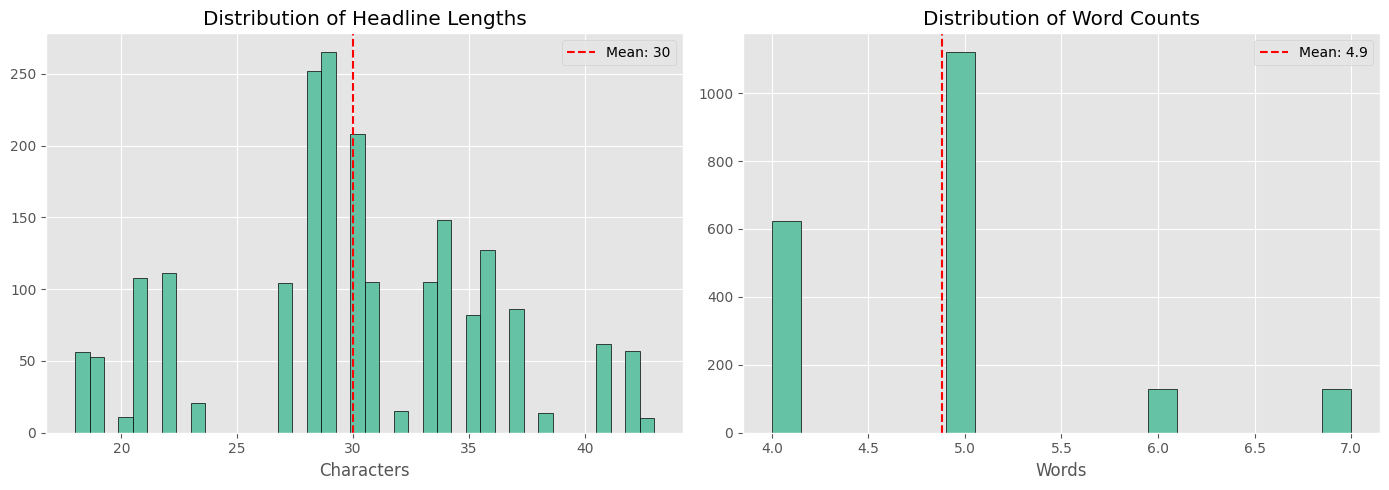

Headline length - Mean: 30, Median: 30
Word count - Mean: 4.9, Median: 5


In [2]:
# Headline length analysis
news_df['headline_length'] = news_df['headline'].str.len()
news_df['word_count'] = news_df['headline'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(news_df['headline_length'], bins=40, edgecolor='black')
axes[0].axvline(news_df['headline_length'].mean(), color='red', linestyle='--', label=f'Mean: {news_df["headline_length"].mean():.0f}')
axes[0].set_title('Distribution of Headline Lengths')
axes[0].set_xlabel('Characters')
axes[0].legend()

axes[1].hist(news_df['word_count'], bins=20, edgecolor='black')
axes[1].axvline(news_df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {news_df["word_count"].mean():.1f}')
axes[1].set_title('Distribution of Word Counts')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.tight_layout()
plt.savefig('headline_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Headline length - Mean: {news_df['headline_length'].mean():.0f}, Median: {news_df['headline_length'].median():.0f}")
print(f"Word count - Mean: {news_df['word_count'].mean():.1f}, Median: {news_df['word_count'].median():.0f}")

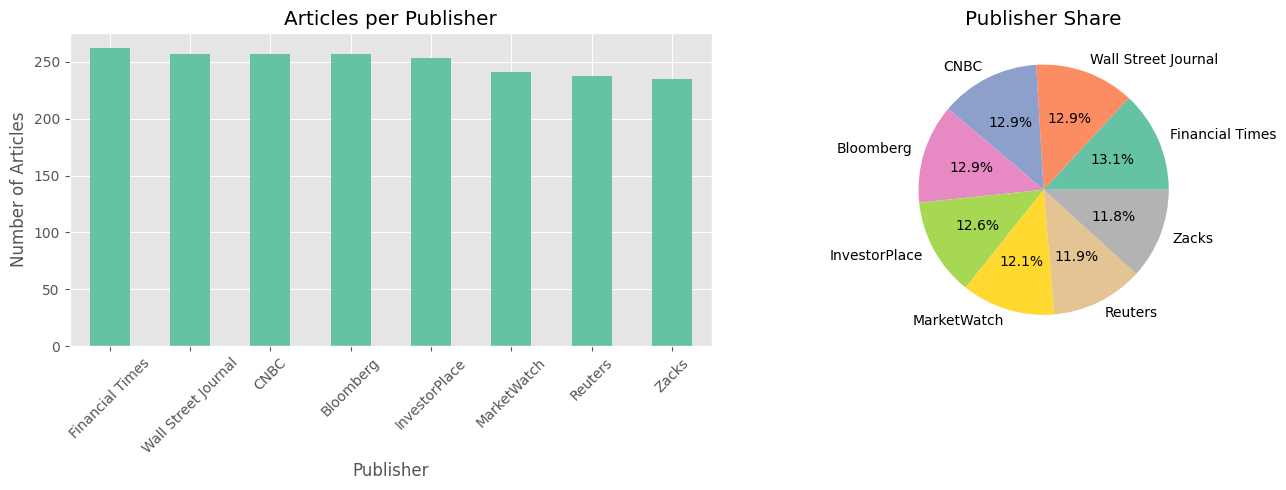

Articles per publisher:
publisher
Financial Times        262
Wall Street Journal    257
CNBC                   257
Bloomberg              257
InvestorPlace          253
MarketWatch            241
Reuters                238
Zacks                  235
Name: count, dtype: int64


In [3]:
# Top publishers
publisher_counts = news_df['publisher'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
publisher_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Articles per Publisher')
axes[0].set_xlabel('Publisher')
axes[0].set_ylabel('Number of Articles')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
publisher_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Publisher Share')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('publisher_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Articles per publisher:")
print(publisher_counts)

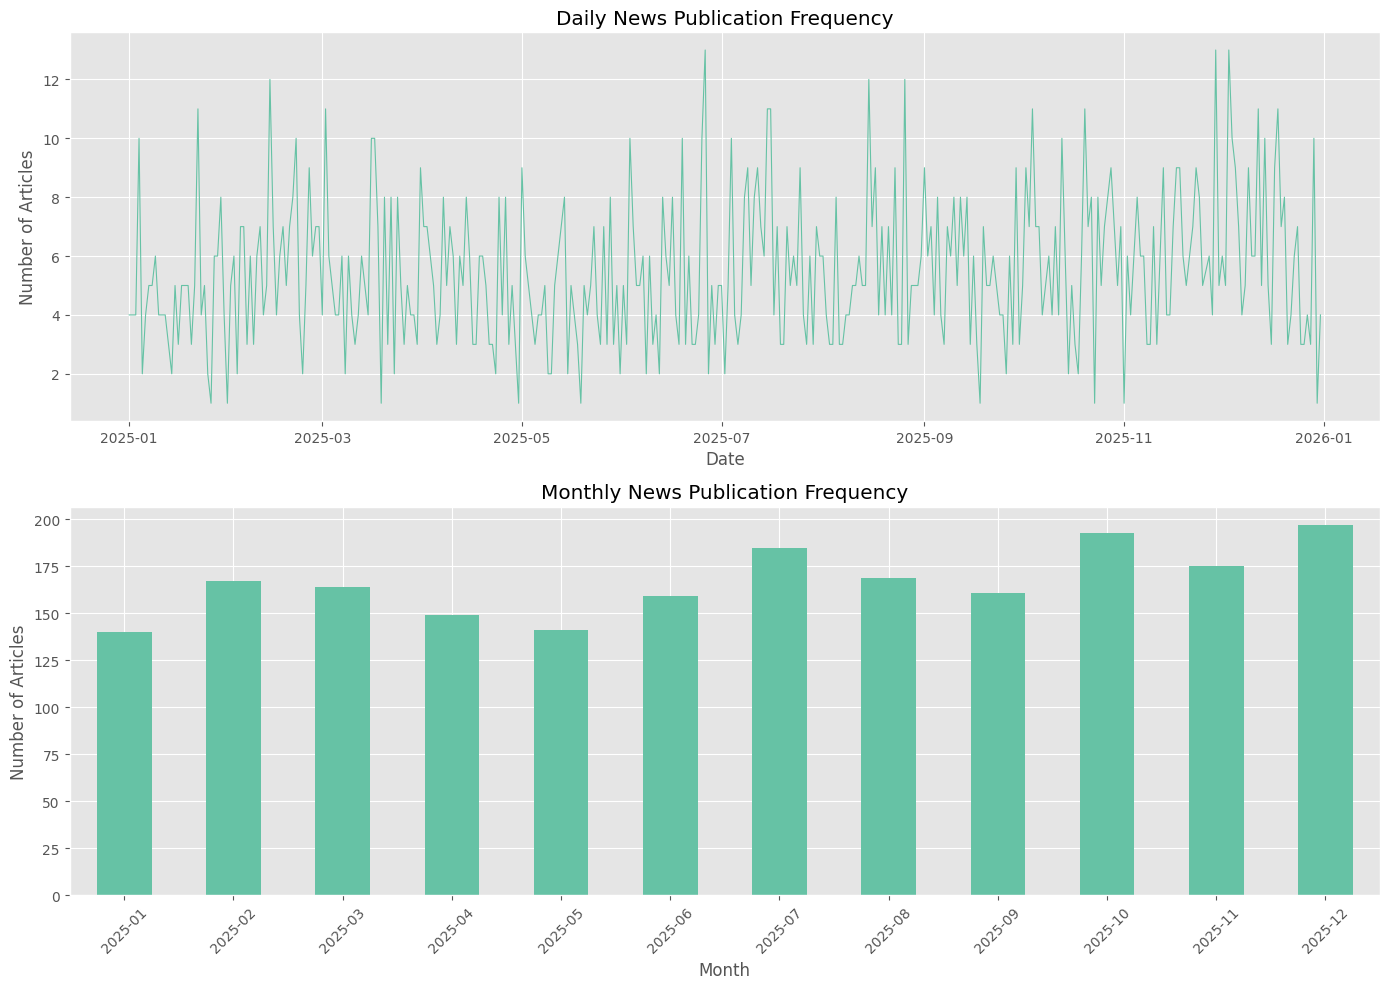

Average articles per day: 5.5
Busiest day: 2025-06-26 with 13 articles


In [4]:
# Daily publication frequency
daily_counts = news_df.groupby(news_df['date'].dt.date).size()

# Monthly publication frequency
news_df['month'] = news_df['date'].dt.to_period('M')
monthly_counts = news_df.groupby('month').size()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily
axes[0].plot(daily_counts.index, daily_counts.values, linewidth=0.8)
axes[0].set_title('Daily News Publication Frequency')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Articles')

# Monthly
monthly_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Monthly News Publication Frequency')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Articles')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('publication_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average articles per day: {daily_counts.mean():.1f}")
print(f"Busiest day: {daily_counts.idxmax()} with {daily_counts.max()} articles")

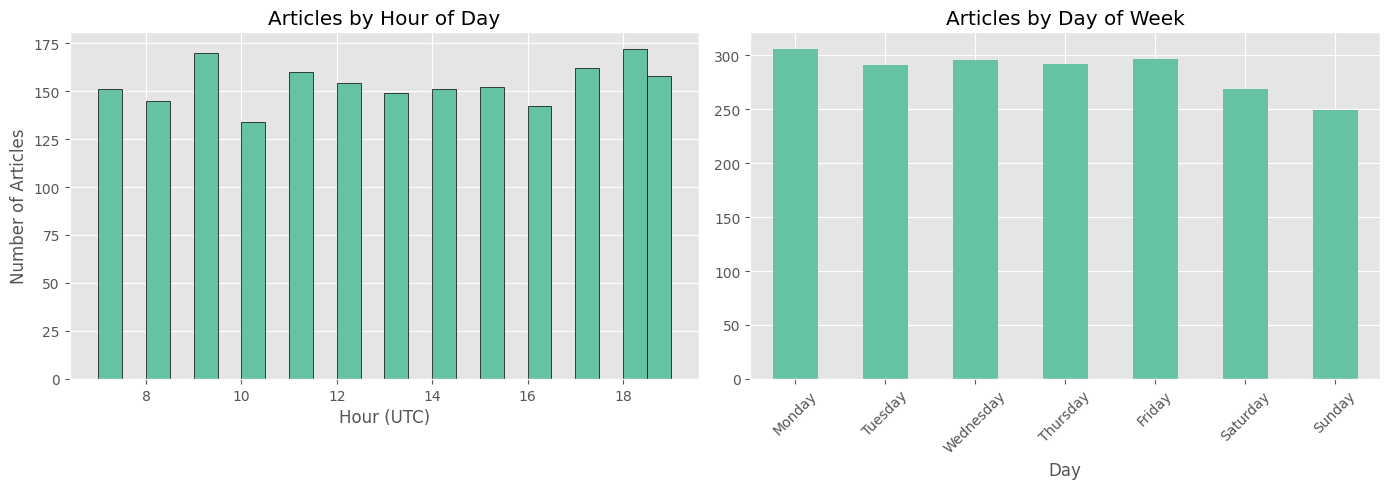

In [5]:
# Hour of publication
news_df['hour'] = news_df['date'].dt.hour
news_df['day_of_week'] = news_df['date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour distribution
news_df['hour'].hist(bins=24, ax=axes[0], edgecolor='black')
axes[0].set_title('Articles by Hour of Day')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Number of Articles')

# Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = news_df['day_of_week'].value_counts().reindex(day_order)
day_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Articles by Day of Week')
axes[1].set_xlabel('Day')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('publishing_time.png', dpi=150, bbox_inches='tight')
plt.show()

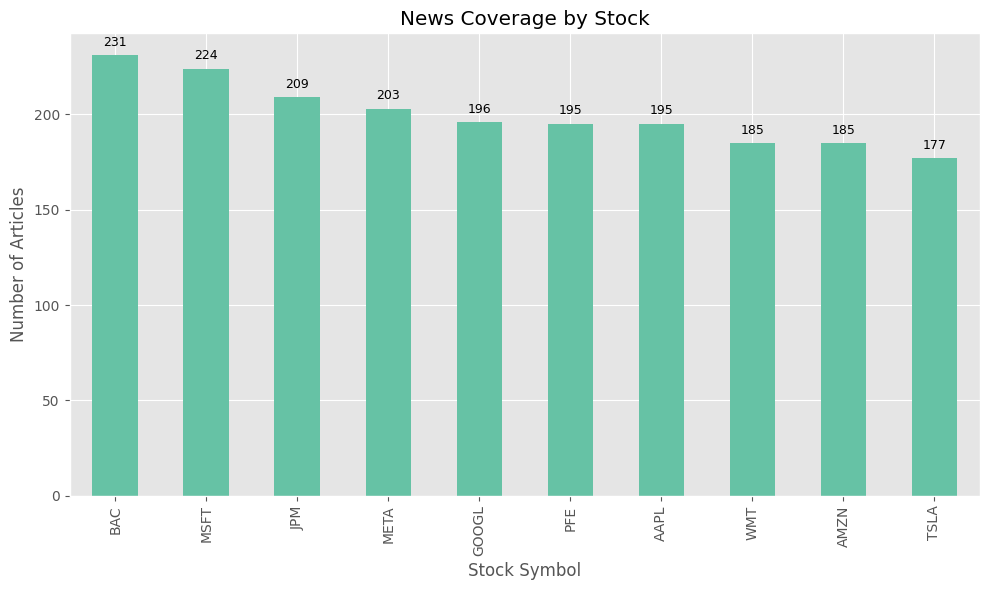

In [6]:
# Articles per stock
stock_counts = news_df['stock'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
stock_counts.plot(kind='bar', ax=ax)
ax.set_title('News Coverage by Stock')
ax.set_xlabel('Stock Symbol')
ax.set_ylabel('Number of Articles')

# Add count labels on bars
for i, v in enumerate(stock_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('stock_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

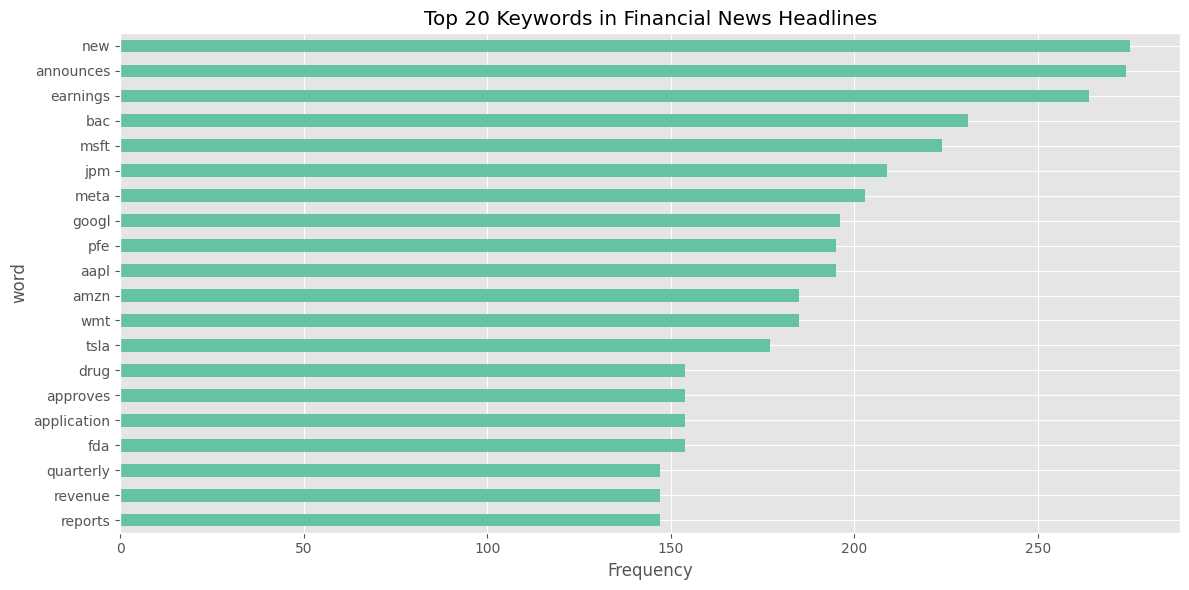

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# Extract common words (excluding stop words)
vectorizer = CountVectorizer(stop_words='english', max_features=30)
word_matrix = vectorizer.fit_transform(news_df['headline'])
word_freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_matrix.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

# Plot top keywords
fig, ax = plt.subplots(figsize=(12, 6))
word_freq.head(20).plot(kind='barh', x='word', y='count', ax=ax, legend=False)
ax.set_title('Top 20 Keywords in Financial News Headlines')
ax.set_xlabel('Frequency')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('keywords.png', dpi=150, bbox_inches='tight')
plt.show()